In [200]:
import numpy as np
import networkx as nx
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *

from collections import Counter
%load_ext autoreload
%autoreload 2
from scipy.stats import wasserstein_distance
from src.optimization.spectral_regularization import *
from src.optimization.solver import *
from src.optimization.objectives import *
import yaml

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [157]:
def get_opt_pm():
    with open("../configs/optimization_parameters.yaml", "r") as file:
        config = yaml.safe_load(file)
    config = config['optimization']
    return config['temperature'],config['alpha_diffusion'],config['time'],config['localized_nodes'],config['lambda_reg']
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()

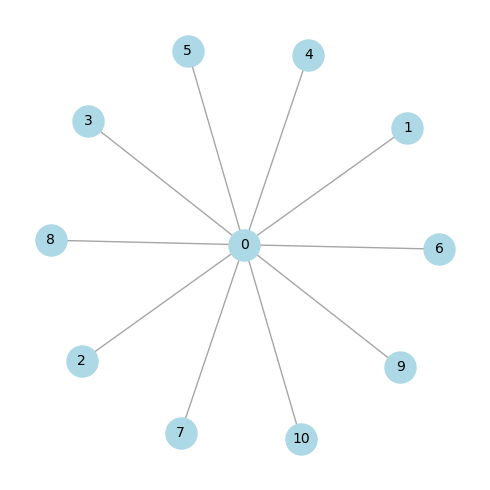

Counter({np.float64(0.0): 330})


In [158]:
#G = nx.random_geometric_graph(n=50, radius=0.35, dim=2, seed=42)
#pos = {node[0]: node[1]['pos'] for node in G.nodes(data=True)}
G = nx.star_graph(n=10)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

In [159]:
E_gromov = gromov_energy(quads, dist_matrix)
#W_local  = local_weights_distance_based(quads, localized_nodes, dist_matrix)
#W_local = np.full(shape=len(quads),fill_value=1/len(quads))
cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

#plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
#plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")


La cost function e' 0.0 - -0.05799092654460526: 0.05799092654460526


In [160]:
#G = nx.random_geometric_graph(n=50, radius=0.35, dim=2, seed=42)
#pos = {node[0]: node[1]['pos'] for node in G.nodes(data=True)}
G = nx.star_graph(n=10)
pos = draw_layout(G)
G.add_edge(4,5)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
#draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

Counter({np.float64(0.0): 330})


In [124]:
E_gromov = gromov_energy(quads, dist_matrix)
cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")


La cost function e' 0.0 - -0.05799092654460526: 0.05799092654460526


In [133]:
#G = nx.random_geometric_graph(n=50, radius=0.35, dim=2, seed=42)
#pos = {node[0]: node[1]['pos'] for node in G.nodes(data=True)}
G = nx.star_graph(n=10)
pos = draw_layout(G)
G.add_edge(4,5)
G.add_edge(1,4)

dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
#draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

Counter({np.float64(0.0): 322, np.float64(0.5): 8})


In [134]:
E_gromov = gromov_energy(quads, dist_matrix)
cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

La cost function e' 0.5 - -0.020794415416798356: 0.5207944154167985


In [131]:
#G = nx.random_geometric_graph(n=50, radius=0.35, dim=2, seed=42)
#pos = {node[0]: node[1]['pos'] for node in G.nodes(data=True)}
G = nx.star_graph(n=10)
pos = draw_layout(G)
G.add_edge(4,5)
G.add_edge(1,4)
G.add_edge(3,5)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
#draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

Counter({np.float64(0.0): 315, np.float64(0.5): 15})


In [132]:
E_gromov = gromov_energy(quads, dist_matrix)
cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")


La cost function e' 0.5 - -0.027080502011022103: 0.5270805020110221


----------

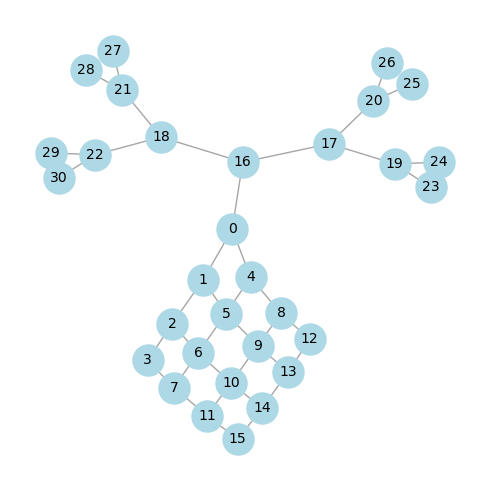

Counter({np.float64(0.0): 27849, np.float64(1.0): 3192, np.float64(2.0): 408, np.float64(3.0): 16})


In [207]:
G = make_tree_with_grid()
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

In [210]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")


La cost function e' 3.0 - -0.027725887222397813: 3.0277258872223975


La cost function e' 1.330565982133947 - 0.18581778118352282: 1.1447482009504244


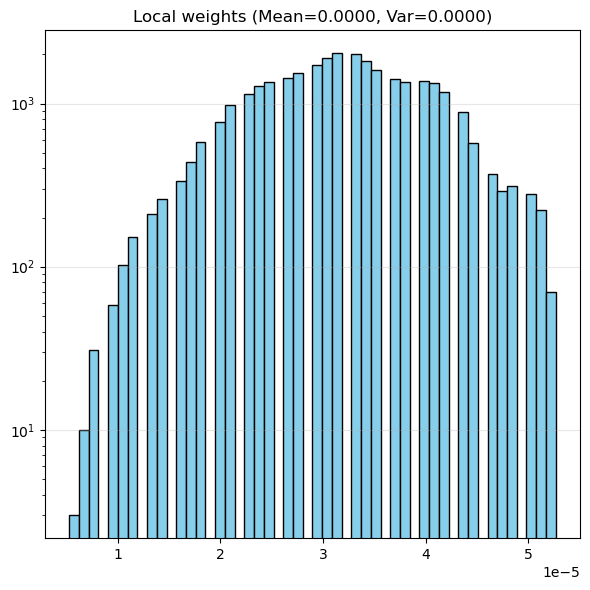

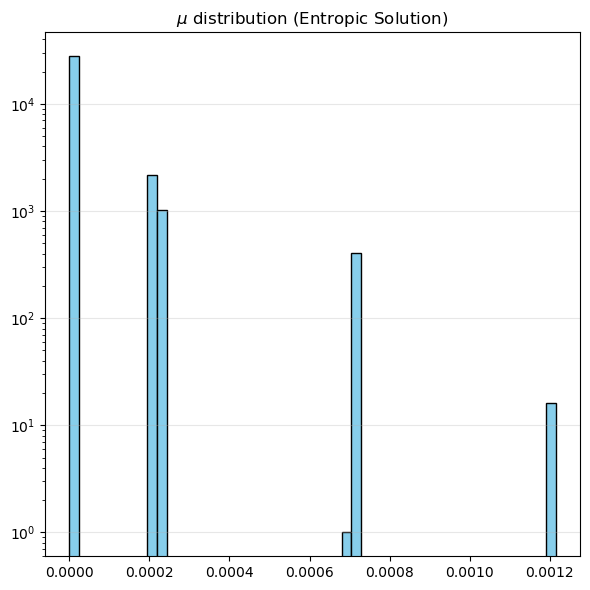

In [211]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads,localized_nodes,dist_matrix)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")


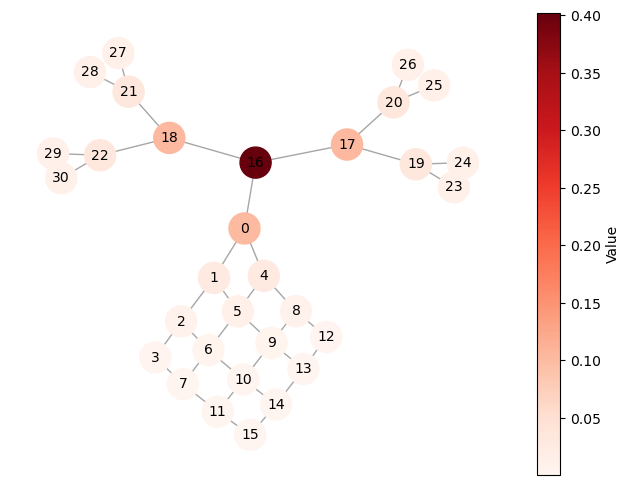

La cost function e' 3.00000000000002 - 0.031267666942692465: 2.968732333057328


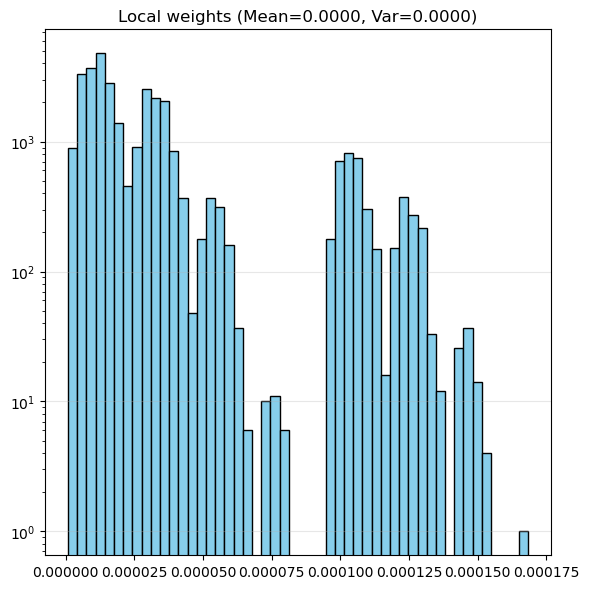

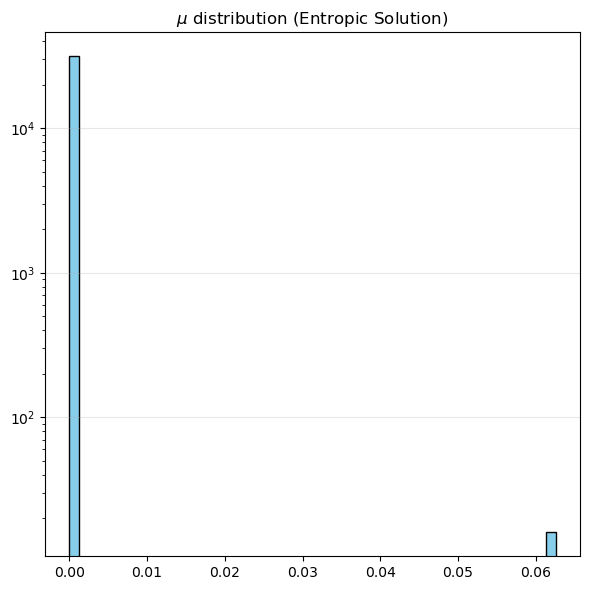

In [218]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_alpha(quads,localized_nodes,L_normalized,alpha_diffusion)

results = diffuse_signal_denoising_solve([localized_nodes], L_normalized, alpha_diffusion)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")


Too many quadruples to visualize (10), showing only the first 9.


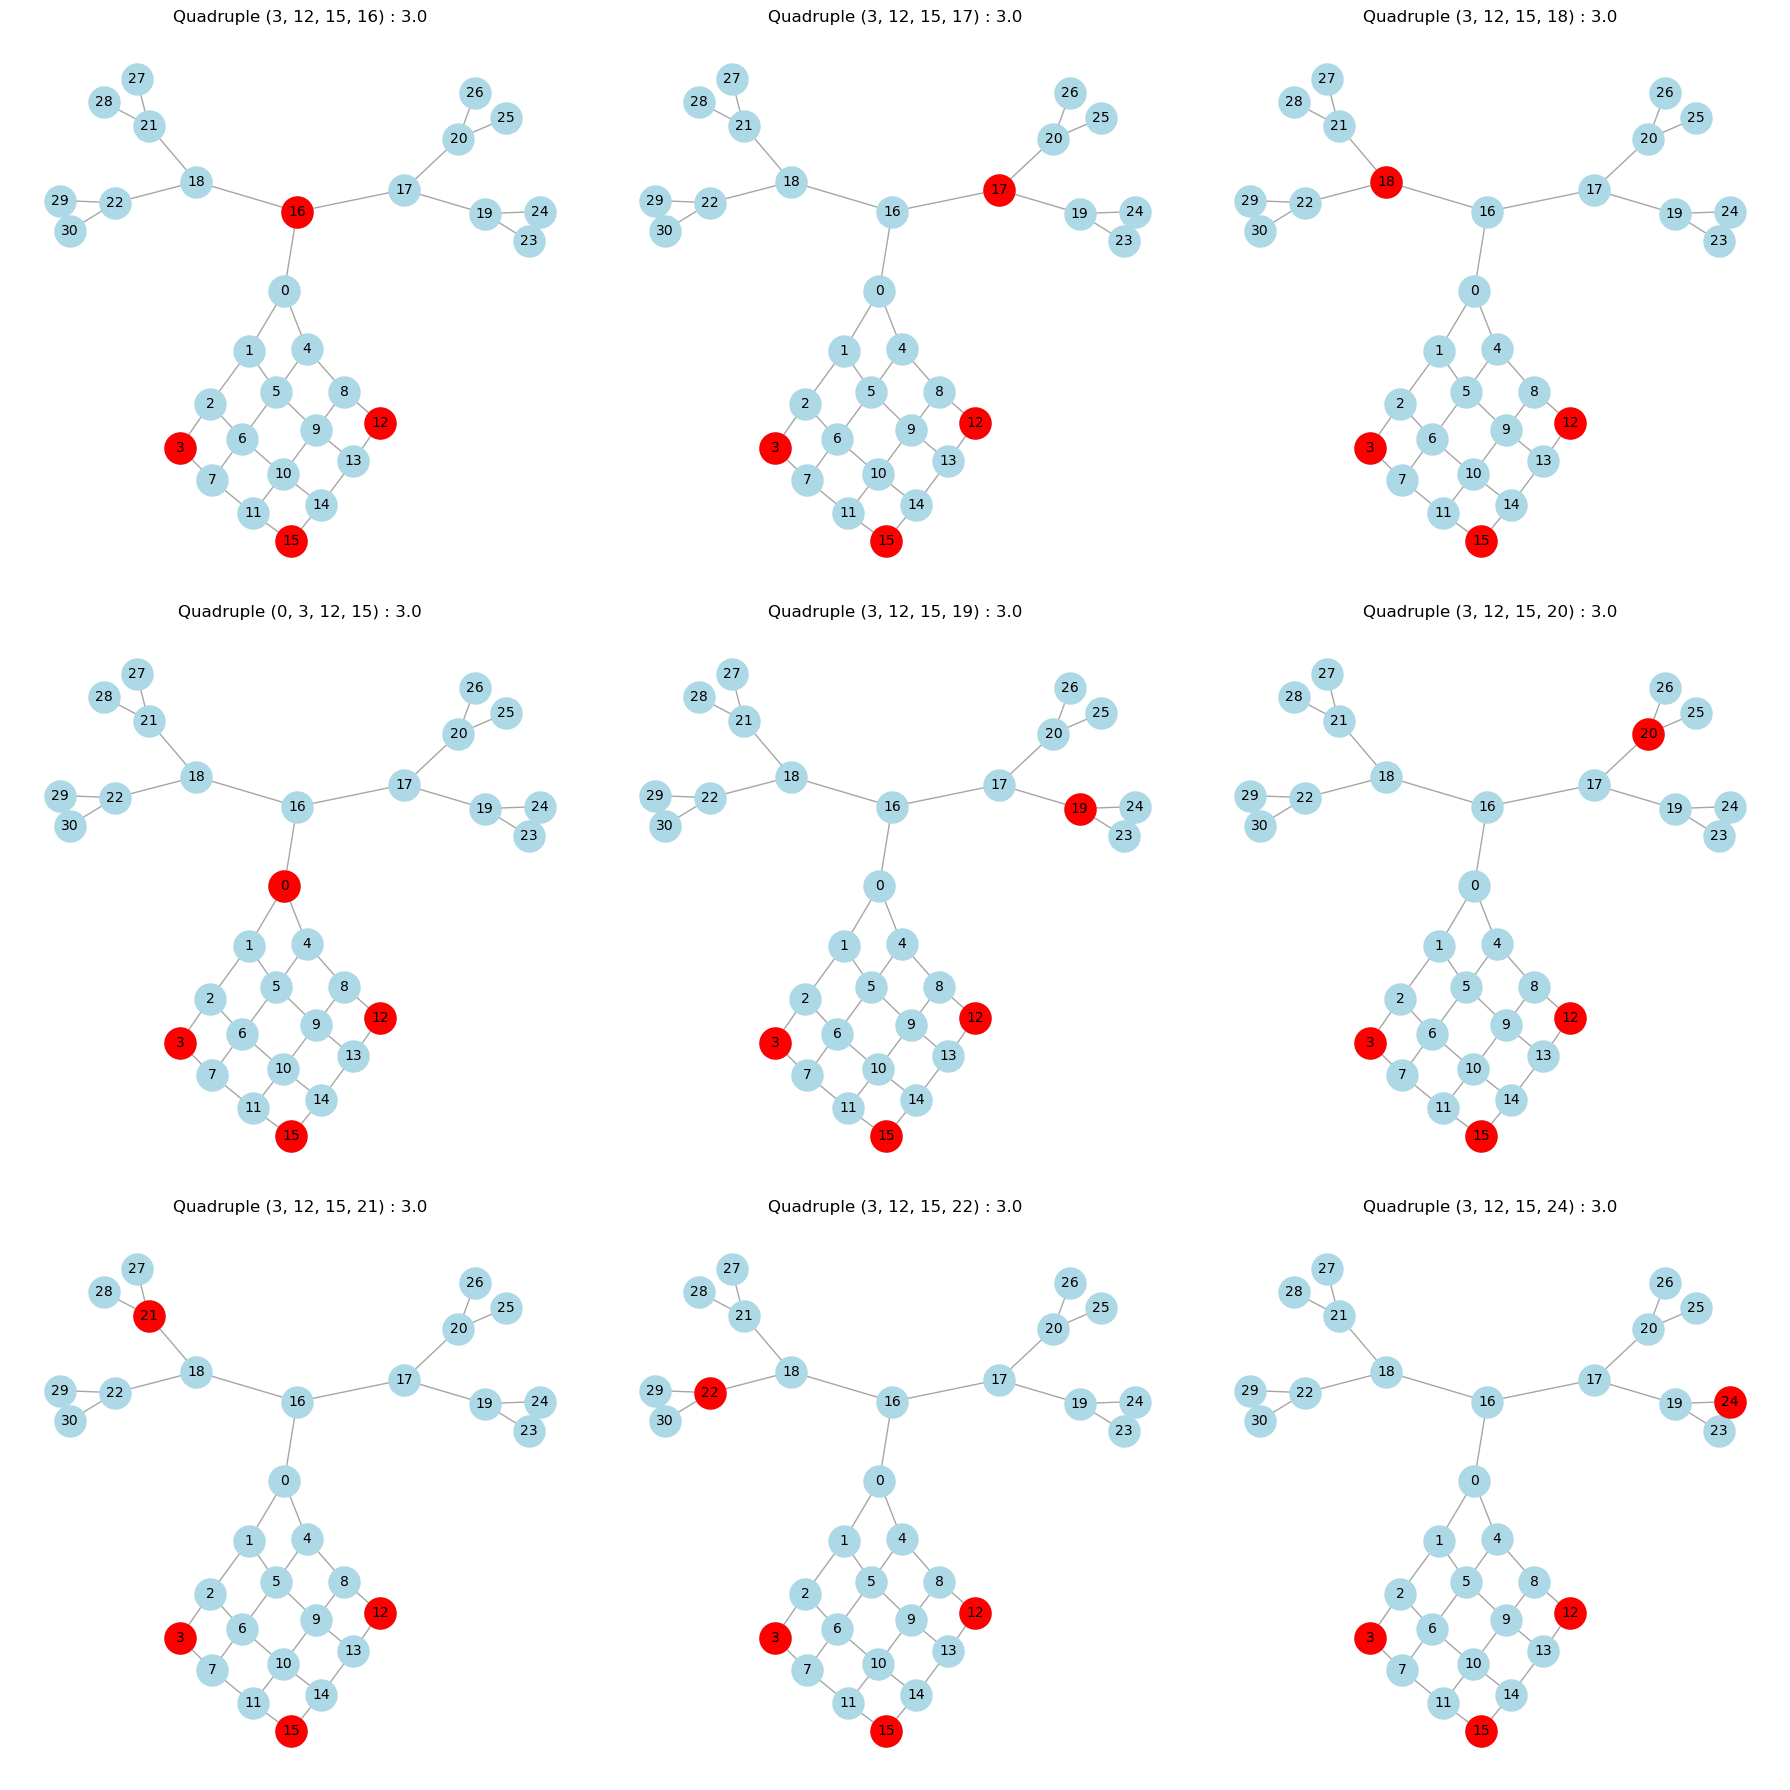

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (3, 12, 15, 16) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 17) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 18) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (0, 3, 12, 15) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 19) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 20) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 21) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 22) : 3.0'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 24) : 3.0'}>],
       dtype=object))

In [219]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]


draw_quadruples(G,pos,top_quads, top_deltas, max_to_draw=9)

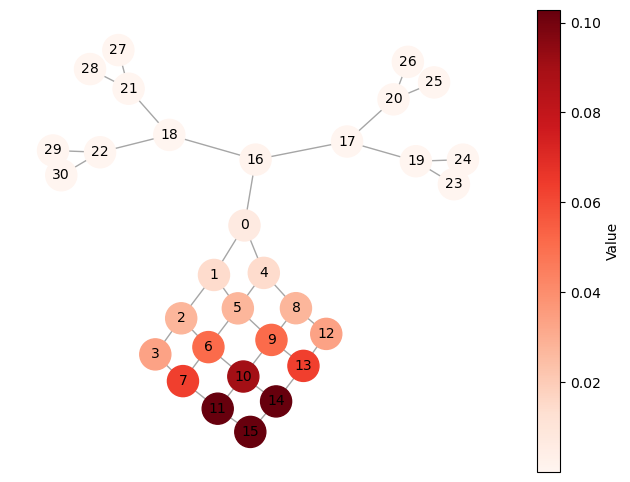

La cost function e' 1.3320486500367394 - 0.16157002305630874: 1.1704786269804308


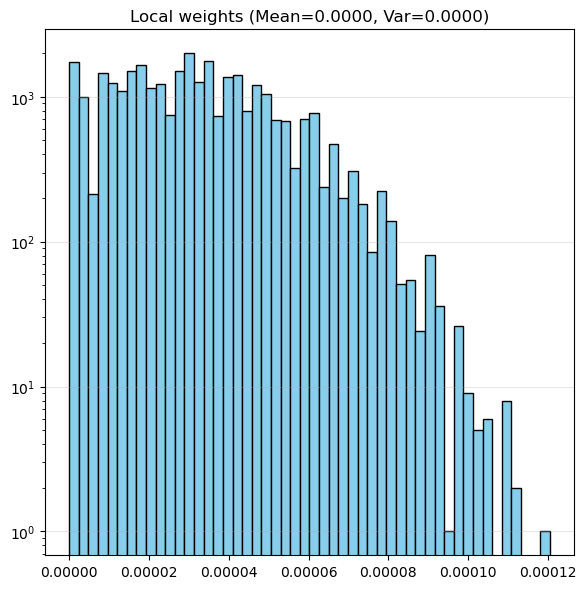

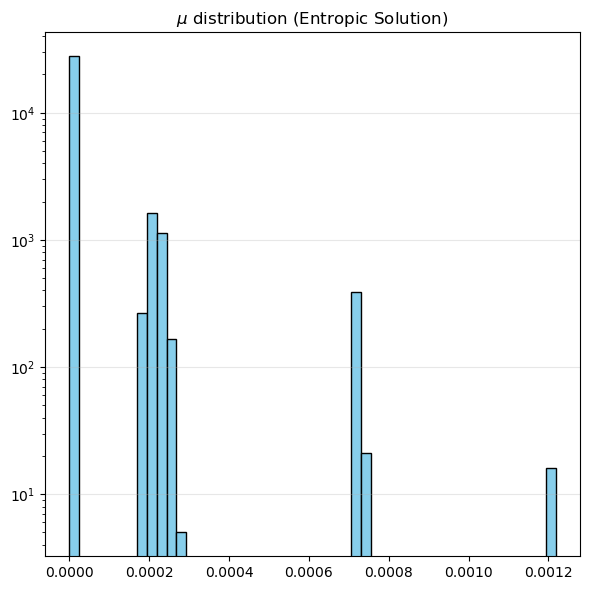

In [204]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_time(quads,localized_nodes,L_normalized,time)

results = diffuse_signal_heat_kernel([localized_nodes], L_normalized, time)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

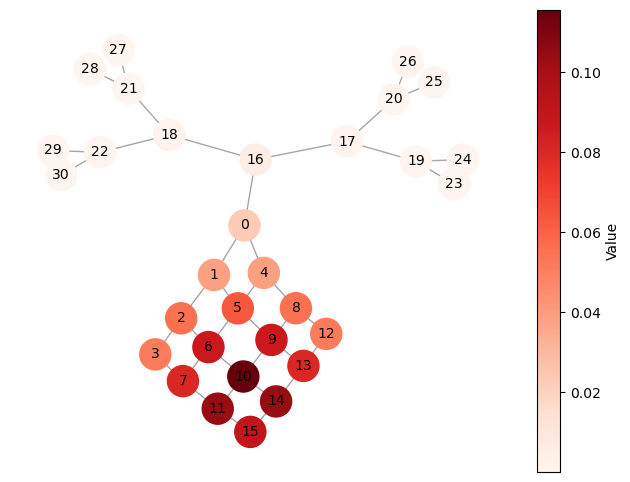

La cost function e' 0.542778865326504 - 0.19654243122408646: 0.34623643410241745


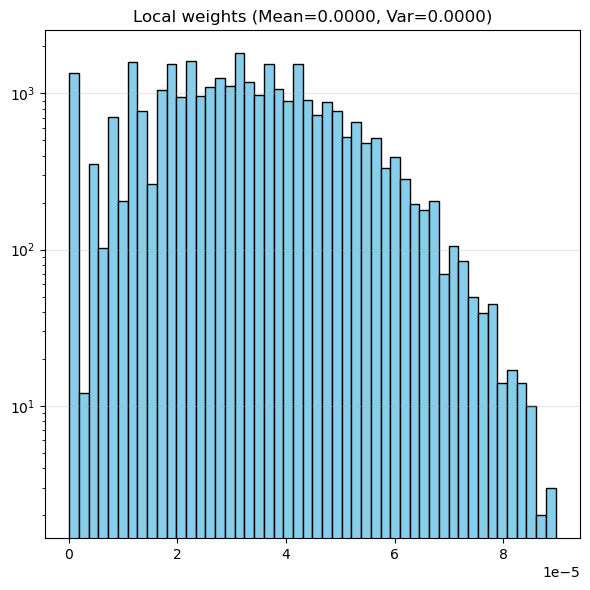

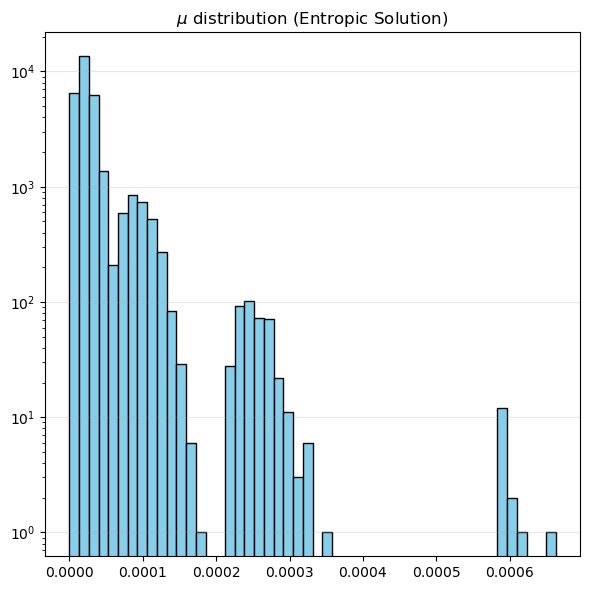

In [193]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_time(quads,localized_nodes,L_normalized,time)

results = diffuse_signal_heat_kernel([localized_nodes], L_normalized, time)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_KL_regularization(cost_vector, W_local, temperature)

first_term = mu * cost_vector
second_term = KL_divergence(mu, W_local, temperature)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

-----------

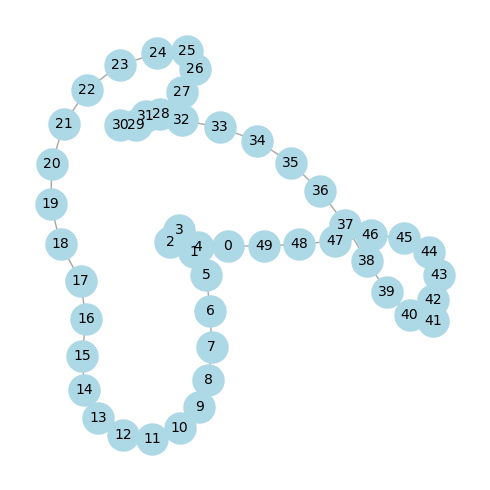

Counter({np.float64(0.0): 115000, np.float64(1.0): 26475, np.float64(2.0): 22075, np.float64(3.0): 18075, np.float64(4.0): 14475, np.float64(5.0): 11275, np.float64(6.0): 8475, np.float64(7.0): 6075, np.float64(8.0): 4075, np.float64(9.0): 2475, np.float64(10.0): 1275, np.float64(11.0): 475, np.float64(12.0): 75})


In [220]:
G = nx.cycle_graph(n=50)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

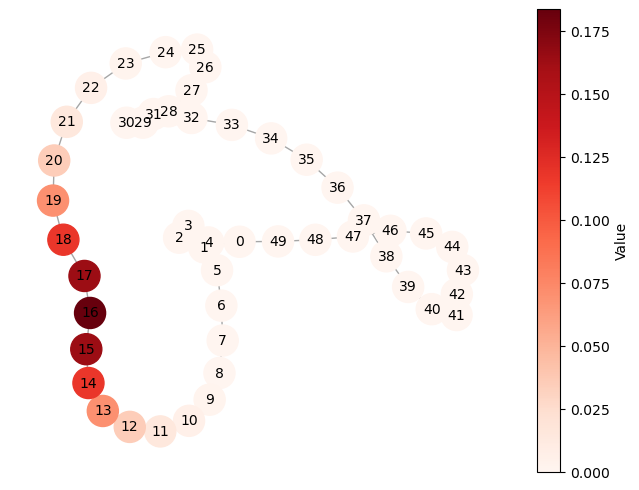

La cost function e' 12.00000000000438 - 0.006667242428092282: 11.99333275757629


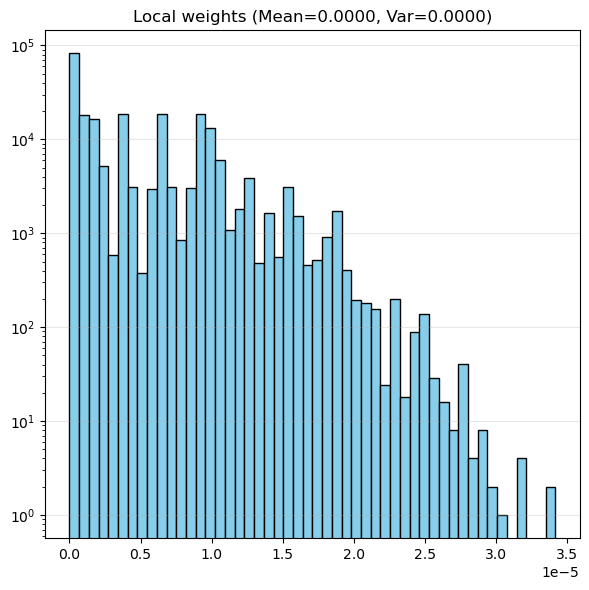

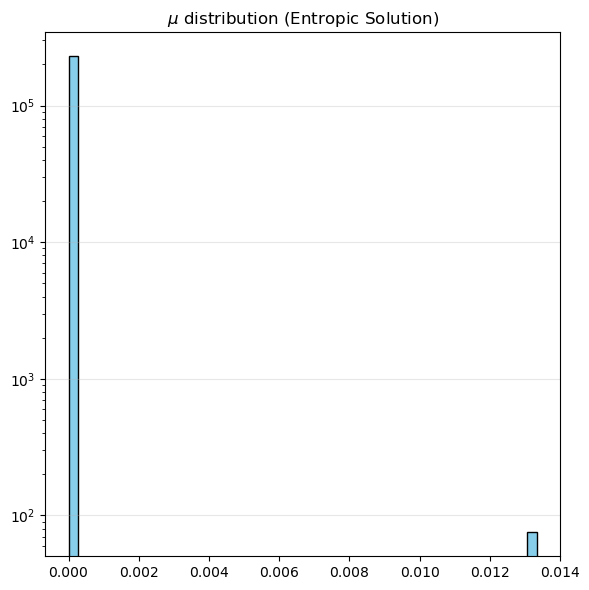

In [221]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_time(quads,localized_nodes,L_normalized,time)

results = diffuse_signal_heat_kernel([localized_nodes], L_normalized, time)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

Too many quadruples to visualize (10), showing only the first 9.


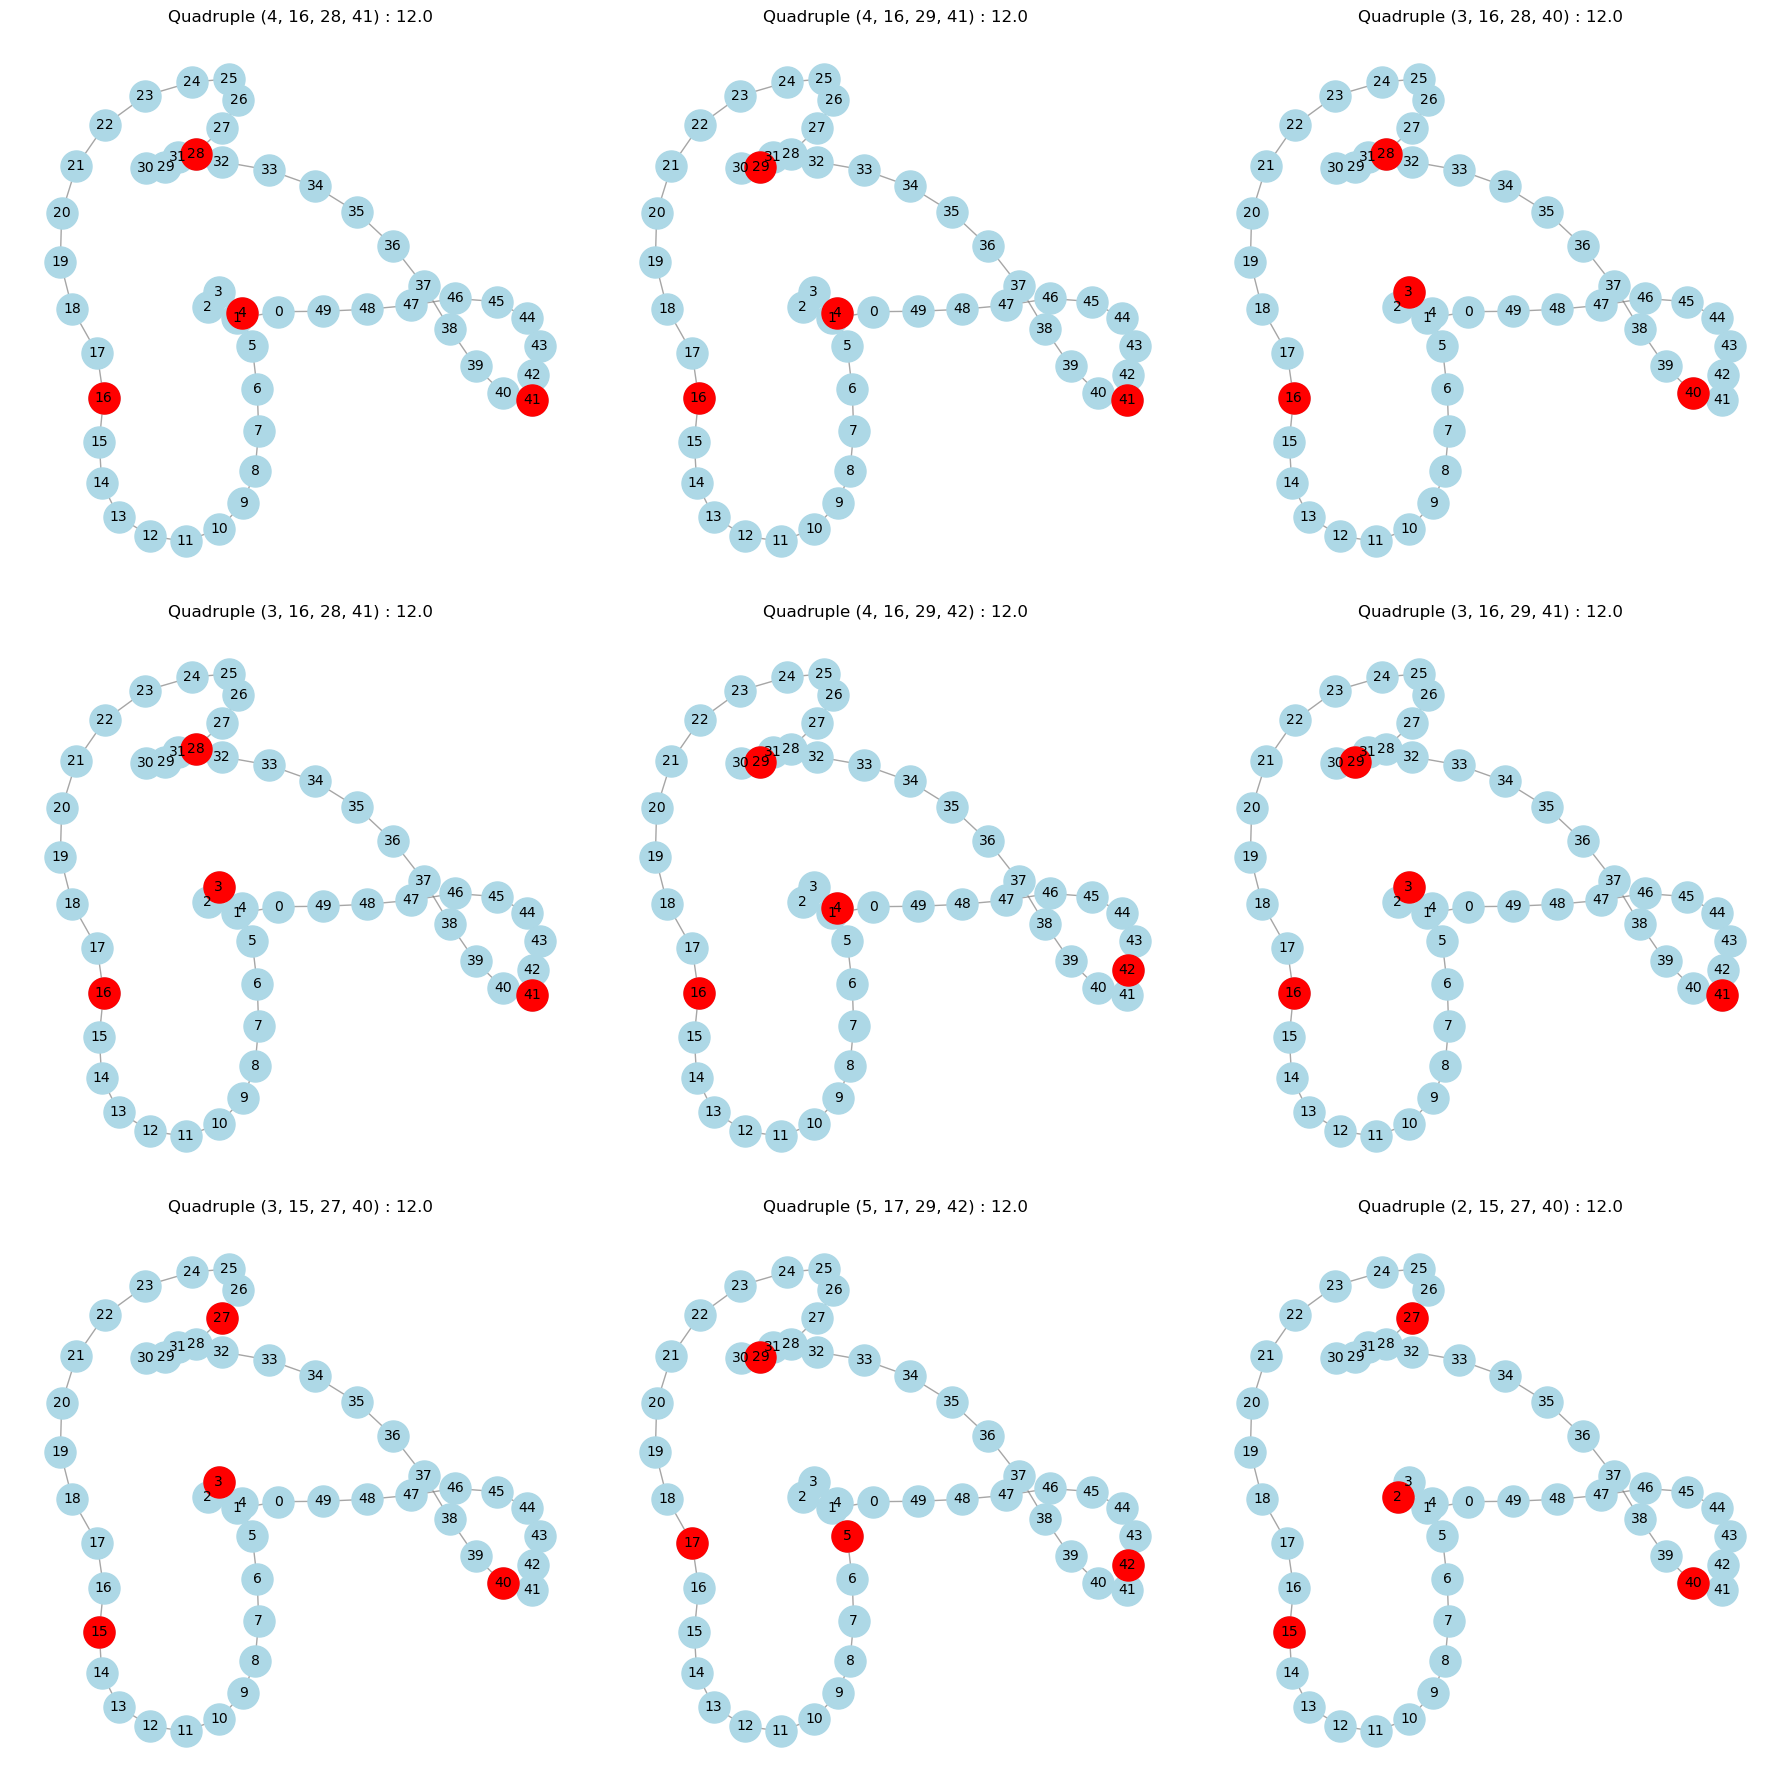

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (4, 16, 28, 41) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (4, 16, 29, 41) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (3, 16, 28, 40) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (3, 16, 28, 41) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (4, 16, 29, 42) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (3, 16, 29, 41) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (3, 15, 27, 40) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (5, 17, 29, 42) : 12.0'}>,
        <Axes: title={'center': 'Quadruple (2, 15, 27, 40) : 12.0'}>],
       dtype=object))

In [222]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]


draw_quadruples(G,pos,top_quads, top_deltas, max_to_draw=9)

[0, 1, 2, 16]
[0, 1, 3, 16]
[0, 1, 4, 16]
[0, 1, 5, 16]
[0, 1, 6, 16]
[0, 1, 7, 16]
[0, 1, 8, 16]
[0, 1, 9, 16]
[0, 1, 10, 16]
[0, 1, 11, 16]
[0, 1, 12, 16]
[0, 1, 13, 16]
[0, 1, 14, 16]
[0, 1, 15, 16]
[0, 1, 16, 17]
[0, 1, 16, 18]
[0, 1, 16, 19]
[0, 1, 16, 20]
[0, 1, 16, 21]
[0, 1, 16, 22]
[0, 1, 16, 23]
[0, 1, 16, 24]
[0, 1, 16, 25]
[0, 1, 16, 26]
[0, 1, 16, 27]
[0, 1, 16, 28]
[0, 1, 16, 29]
[0, 1, 16, 30]
[0, 1, 16, 31]
[0, 1, 16, 32]
[0, 1, 16, 33]
[0, 1, 16, 34]
[0, 1, 16, 35]
[0, 1, 16, 36]
[0, 1, 16, 37]
[0, 1, 16, 38]
[0, 1, 16, 39]
[0, 1, 16, 40]
[0, 1, 16, 41]
[0, 1, 16, 42]
[0, 1, 16, 43]
[0, 1, 16, 44]
[0, 1, 16, 45]
[0, 1, 16, 46]
[0, 1, 16, 47]
[0, 1, 16, 48]
[0, 1, 16, 49]
[0, 2, 3, 16]
[0, 2, 4, 16]
[0, 2, 5, 16]
[0, 2, 6, 16]
[0, 2, 7, 16]
[0, 2, 8, 16]
[0, 2, 9, 16]
[0, 2, 10, 16]
[0, 2, 11, 16]
[0, 2, 12, 16]
[0, 2, 13, 16]
[0, 2, 14, 16]
[0, 2, 15, 16]
[0, 2, 16, 17]
[0, 2, 16, 18]
[0, 2, 16, 19]
[0, 2, 16, 20]
[0, 2, 16, 21]
[0, 2, 16, 22]
[0, 2, 16, 23]
[0, 2, 16,

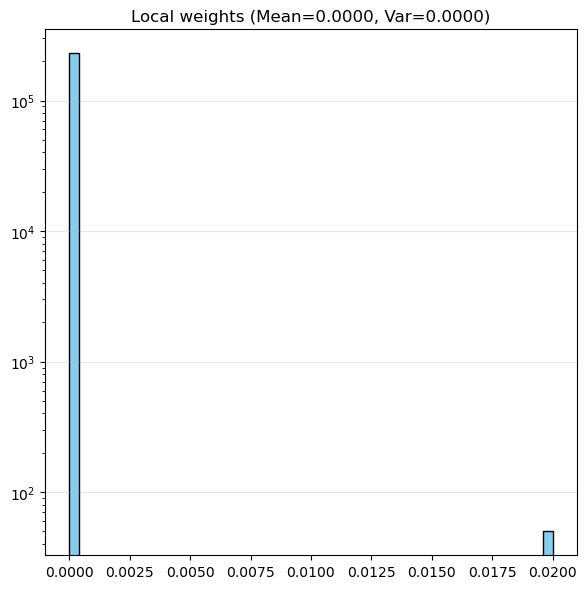

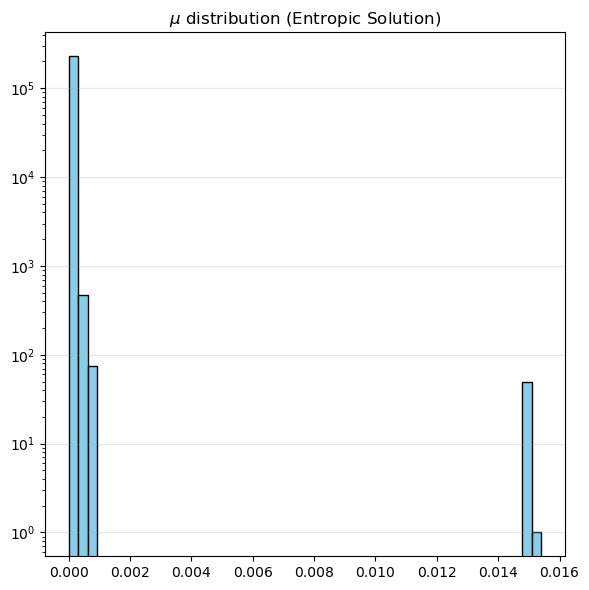

In [233]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = np.zeros(len(quads))
for quad in quads:
    if any(x in quad for x in [16]):
        print(list(quad))
        W_local[list(quad)] = 1
W_local /= np.sum(W_local)


cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

In [231]:
top_mu

[np.float64(0.01539499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996),
 np.float64(0.01489499999999996)]

In [232]:
W_local

array([0.02, 0.02, 0.02, ..., 0.  , 0.  , 0.  ], shape=(230300,))

Too many quadruples to visualize (10), showing only the first 9.


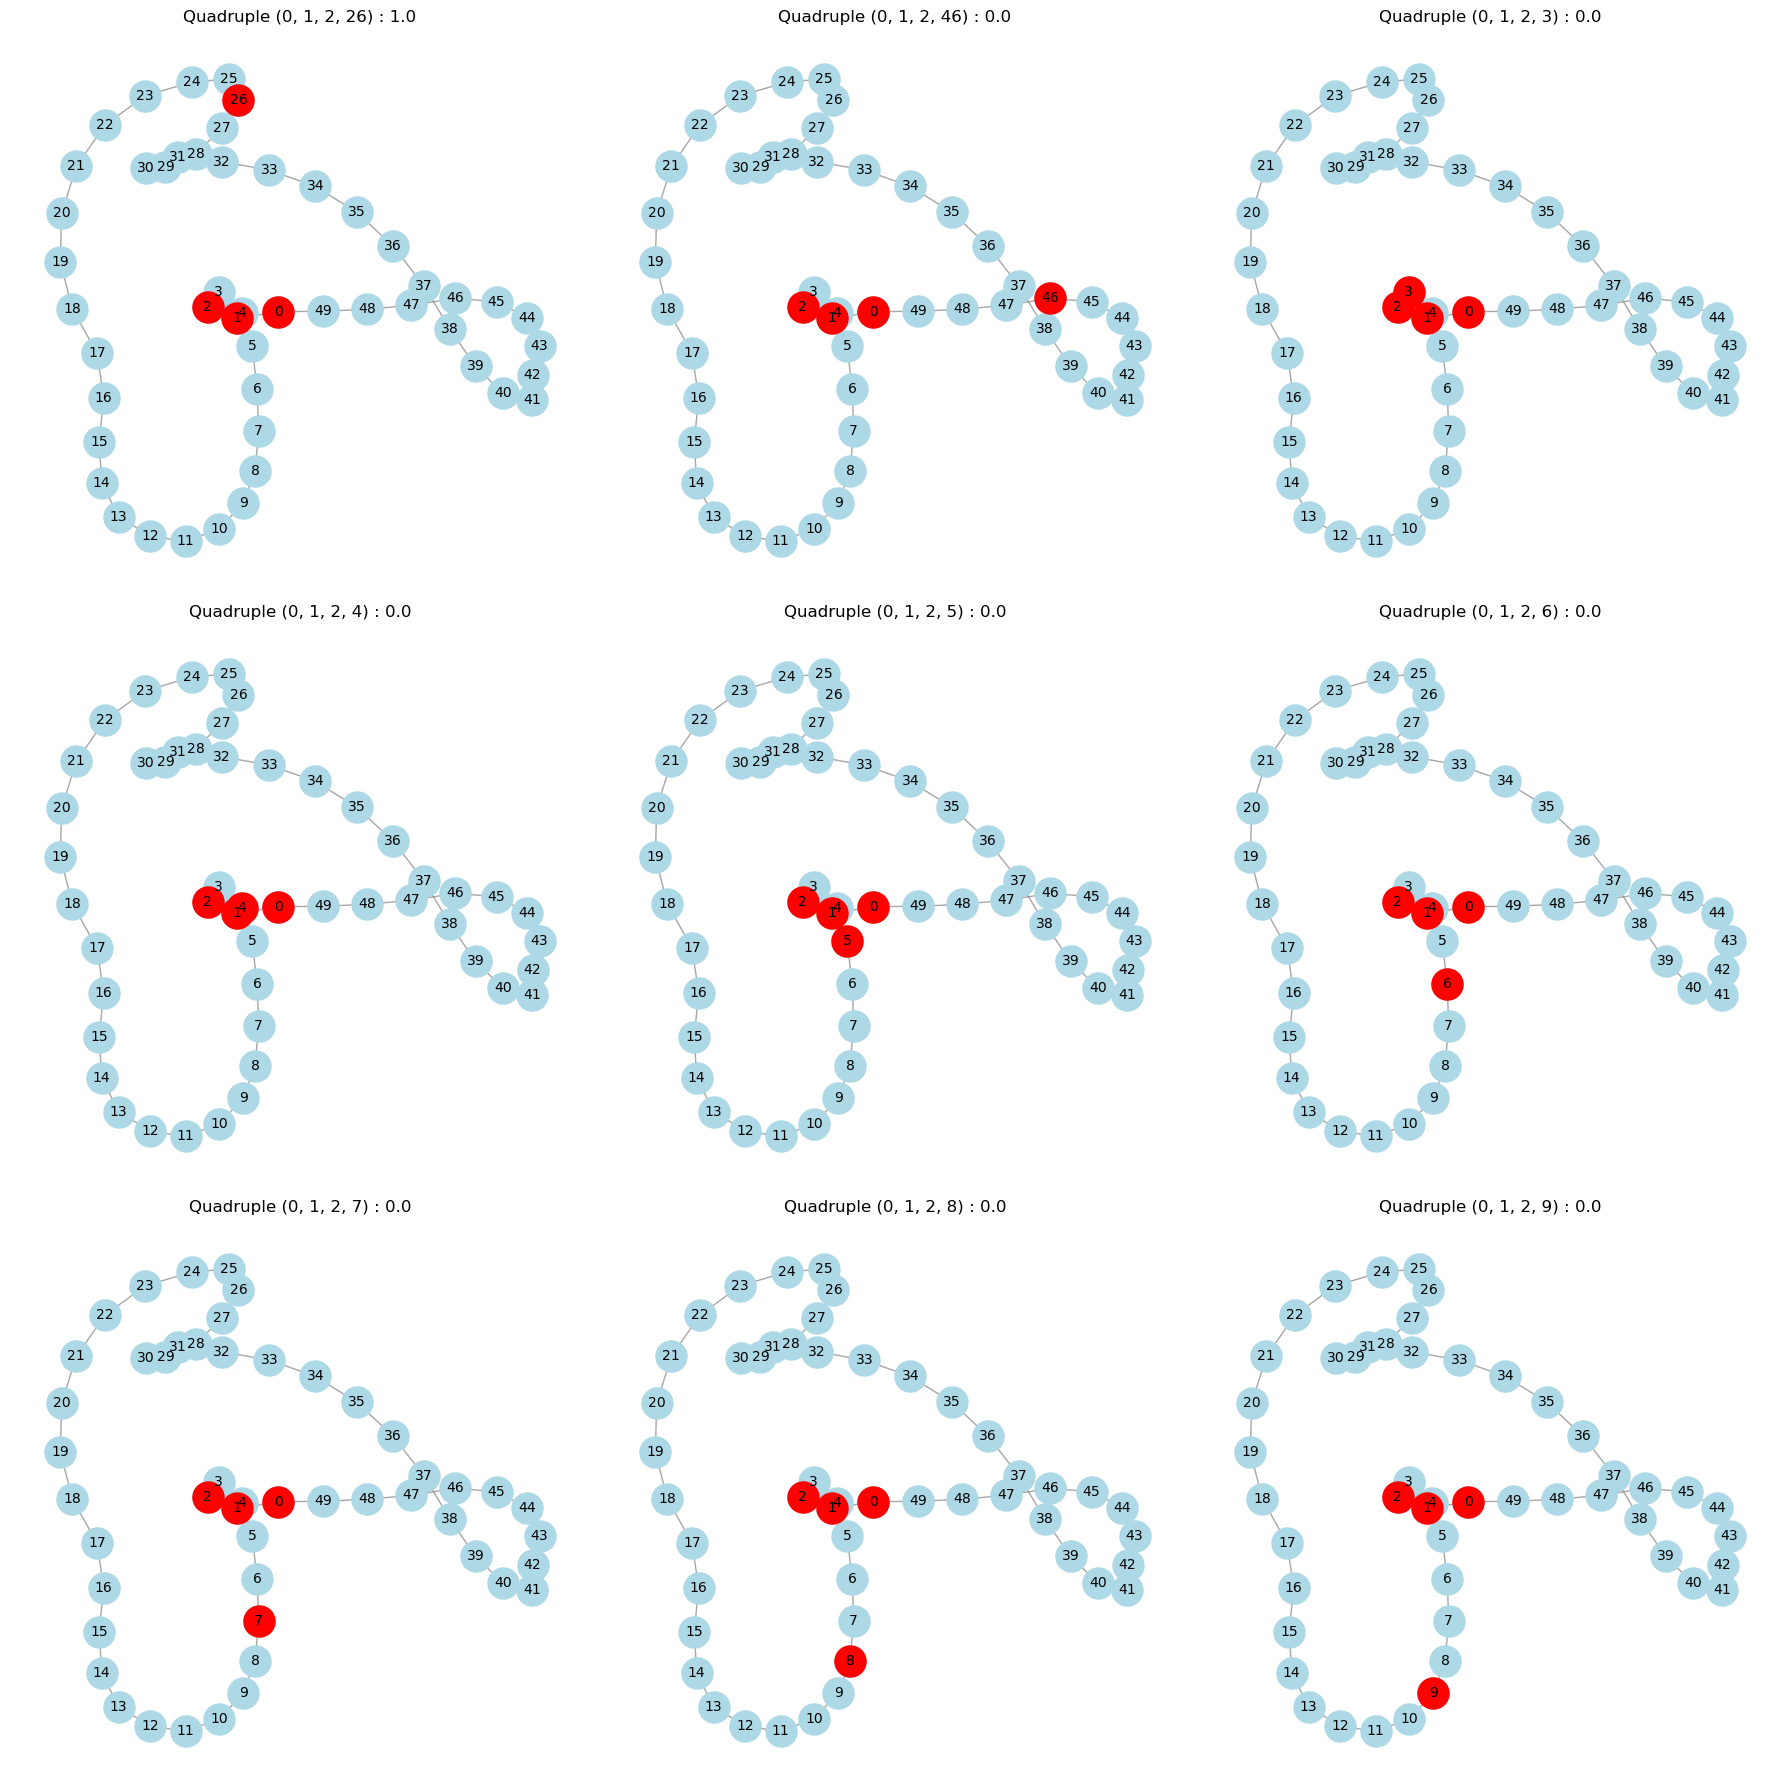

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 1, 2, 26) : 1.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 46) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 3) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 4) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 5) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 6) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 7) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 8) : 0.0'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 9) : 0.0'}>],
       dtype=object))

In [230]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu = [mu[i] for i in top_indices]


draw_quadruples(G,pos,top_quads, top_deltas, max_to_draw=9)